In [15]:
import yfinance as yf
import pandas as pd

# List of stocks
top_30_stocks = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "META", "NVDA", "BRK-B", "V", "JNJ",
    "WMT", "PG", "JPM", "UNH", "HD", "MA", "XOM", "DIS", "NFLX", "KO",
    "PEP", "PFE", "MRK", "ABBV", "TMO", "AVGO", "COST", "ADBE", "INTC", "CSCO"
]


# Download historical data for the past 3 years
YF_DATA = yf.download(top_30_stocks, period="3y", interval="1d")

# Save to CSV
YF_DATA.to_csv("stock_data_3years.csv")
print("Stock data for the past 3 years saved to stock_data_3years.csv")

# Show first few rows
print(YF_DATA.head(5),YF_DATA.shape)


[*********************100%***********************]  30 of 30 completed


Stock data for the past 3 years saved to stock_data_3years.csv
Price            Close                                                 \
Ticker            AAPL        ABBV        ADBE        AMZN       AVGO   
Date                                                                    
2022-03-14  148.218323  135.876801  411.500000  141.852997  53.071781   
2022-03-15  152.617035  139.253632  421.660004  147.366501  55.404770   
2022-03-16  157.045303  139.405472  442.359985  153.104004  56.746990   
2022-03-17  158.058884  141.674576  444.359985  157.238998  56.331051   
2022-03-18  161.365326  142.219513  453.329987  161.250504  57.054501   

Price                                                                  ...  \
Ticker           BRK-B        COST       CSCO         DIS       GOOGL  ...   
Date                                                                   ...   
2022-03-14  329.980011  504.261536  49.426071  127.455452  125.351692  ...   
2022-03-15  332.549988  519.956604  50.6

In [16]:
YF_DATA.columns


MultiIndex([( 'Close',  'AAPL'),
            ( 'Close',  'ABBV'),
            ( 'Close',  'ADBE'),
            ( 'Close',  'AMZN'),
            ( 'Close',  'AVGO'),
            ( 'Close', 'BRK-B'),
            ( 'Close',  'COST'),
            ( 'Close',  'CSCO'),
            ( 'Close',   'DIS'),
            ( 'Close', 'GOOGL'),
            ...
            ('Volume',  'NVDA'),
            ('Volume',   'PEP'),
            ('Volume',   'PFE'),
            ('Volume',    'PG'),
            ('Volume',   'TMO'),
            ('Volume',  'TSLA'),
            ('Volume',   'UNH'),
            ('Volume',     'V'),
            ('Volume',   'WMT'),
            ('Volume',   'XOM')],
           names=['Price', 'Ticker'], length=150)

In [17]:
new_sorted=YF_DATA.swaplevel(1,0,axis=1)
new_sorted.sort_index(axis=1,inplace=True)
new_sorted.head(1)

Ticker            AAPL                                                \
Price            Close        High         Low       Open     Volume   
Date                                                                   
2022-03-14  148.218323  151.662514  147.706625  149.03509  108732100   

Ticker            ABBV                                               ...  \
Price            Close        High         Low        Open   Volume  ...   
Date                                                                 ...   
2022-03-14  135.876801  136.654001  133.125316  134.652917  8647200  ...   

Ticker            WMT                                                   XOM  \
Price           Close       High        Low       Open    Volume      Close   
Date                                                                          
2022-03-14  46.011826  46.267358  45.353831  45.363412  22646400  73.799843   

Ticker                                                
Price           High        Low       Open    Volume  
Date                                                  
2022-03-14  75.21491  72.556028  74.863397  37462600  

[1 rows x 150 columns]

In [18]:
YF_DATA.info()
YF_DATA.isnull().sum()
YF_DATA.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 754 entries, 2022-03-14 to 2025-03-14
Columns: 150 entries, ('Close', 'AAPL') to ('Volume', 'XOM')
dtypes: float64(120), int64(30)
memory usage: 889.5 KB


np.int64(0)

In [19]:
YF_DATA.describe()

Price        Close                                                  \
Ticker        AAPL        ABBV        ADBE        AMZN        AVGO   
count   754.000000  754.000000  754.000000  754.000000  754.000000   
mean    181.264432  153.206808  458.729416  148.591183  103.734039   
std      32.658247   21.719353   89.335974   40.119470   54.787978   
min     123.583107  122.044968  275.200012   81.820000   40.863617   
25%     154.276196  136.905502  379.277504  115.025002   55.676344   
50%     175.657516  145.651527  462.110001  142.090004   85.408096   
75%     206.515911  169.458179  528.817490  181.602505  140.956337   
max     258.735504  216.660004  634.760010  242.059998  249.331955   

Price                                                                ...  \
Ticker       BRK-B         COST        CSCO         DIS       GOOGL  ...   
count   754.000000   754.000000  754.000000  754.000000  754.000000  ...   
mean    366.047281   642.183333   48.275294   99.674666  135.238665  ...   
std      64.052347   184.368193    5.756647   12.034059   30.445139  ...   
min     264.000000   399.907379   36.651169   78.352066   83.033020  ...   
25%     311.139999   485.806061   44.920377   90.860050  109.821823  ...   
50%     352.315002   545.479675   47.451988   97.693127  131.944183  ...   
75%     413.764999   814.903137   50.727082  108.794144  162.518848  ...   
max     514.460022  1076.859985   64.870003  140.642548  206.142593  ...   

Price         Volume                                                          \
Ticker          NVDA           PEP           PFE            PG           TMO   
count   7.540000e+02  7.540000e+02  7.540000e+02  7.540000e+02  7.540000e+02   
mean    4.490236e+08  5.296323e+06  3.072769e+07  6.693270e+06  1.542566e+06   
std     1.710620e+08  2.125367e+06  1.609390e+07  2.520193e+06  6.867661e+05   
min     1.051570e+08  1.751700e+06  6.760200e+06  2.132500e+06  4.887000e+05   
25%     3.402559e+08  4.043775e+06  2.005848e+07  5.257300e+06  1.085875e+06   
50%     4.353360e+08  4.909000e+06  2.699910e+07  6.143600e+06  1.375250e+06   
75%     5.398382e+08  5.859575e+06  3.657138e+07  7.453025e+06  1.846700e+06   
max     1.543911e+09  2.188120e+07  1.581007e+08  2.864750e+07  7.906700e+06   

Price                                                                         
Ticker          TSLA           UNH             V           WMT           XOM  
count   7.540000e+02  7.540000e+02  7.540000e+02  7.540000e+02  7.540000e+02  
mean    1.066840e+08  3.579165e+06  6.568464e+06  1.953299e+07  1.847565e+07  
std     3.972094e+07  2.083726e+06  2.985599e+06  1.131854e+07  7.260024e+06  
min     3.716760e+07  1.135000e+06  1.640900e+06  6.287500e+06  6.237057e+06  
25%     7.781815e+07  2.466600e+06  4.771225e+06  1.375512e+07  1.366530e+07  
50%     9.999870e+07  3.005600e+06  5.827700e+06  1.684035e+07  1.677830e+07  
75%     1.262412e+08  3.905850e+06  7.388650e+06  2.129505e+07  2.091962e+07  
max     3.065906e+08  2.273420e+07  2.781090e+07  1.329402e+08  6.461020e+07  

[8 rows x 150 columns]

In [20]:
import plotly.express as px
import plotly.figure_factory as ff

# Use your DataFrame name (YF_DATA)
df_close = YF_DATA["Open"].dropna()  # Select closing prices and drop missing values

# 📌 Box Plot - Stock Price Distributions
fig_box = px.box(df_close, title="Stock Price Distribution (Last 3 Years)")
fig_box.show()




In [21]:
import plotly.graph_objects as go

# Ensure 'Date' is datetime
YF_DATA.index = pd.to_datetime(YF_DATA.index)

# Select Apple's Open and Close prices
appel_open = YF_DATA["Open"]["AAPL"].dropna()
appel_close = YF_DATA["Close"]["AAPL"].dropna()
msc_open = YF_DATA["Open"]["MSFT"].dropna()
msc_close = YF_DATA["Close"]["MSFT"].dropna()

# Create the plot
fig = go.Figure()

fig.add_trace(go.Scatter(x=appel_open.index, y=appel_open, mode="lines", name="Open Price", line=dict(color="blue")))
fig.add_trace(go.Scatter(x=appel_close.index, y=appel_close, mode="lines", name="Close Price", line=dict(color="red")))
fig.add_trace(go.Scatter(x=msc_open.index, y=msc_open, mode="lines", name="Open Price", line=dict(color="green")))
fig.add_trace(go.Scatter(x=msc_close.index, y=msc_close, mode="lines", name="Close Price", line=dict(color="red")))
fig.update_layout(title="Apple Stock: Open vs Close Prices",
                  xaxis_title="Date",
                  yaxis_title="Price (USD)",
                  legend_title="Price Type")

fig.show()


In [22]:
ms_apl_opn_crr=appel_open.corr(msc_open)
print(ms_apl_opn_crr)
ms_apl_cls_crr=appel_close.corr(msc_close)
ms_apl_cls_crr

0.8740619439614905


np.float64(0.8736412890779057)

In [23]:

# Select top 6 known companies
top_companies = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "META","NVDA"]

# Convert index to datetime
YF_DATA.index = pd.to_datetime(YF_DATA.index)

# Ensure "Year" is a column in YF_DATA
YF_DATA["Year"] = YF_DATA.index.year

# Loop through each company to create separate bar plots
for company in top_companies:
    # Select Open, Close, High, and Low prices for the company
    company_data = YF_DATA.loc[:, (["Open", "Close", "High", "Low"], company)].copy()

    # Flatten MultiIndex columns
    company_data.columns = ["_".join(col) for col in company_data.columns]

    # Add the Year column
    company_data["Year"] = YF_DATA["Year"]

    # Compute yearly mean
    company_data = company_data.groupby("Year").mean().reset_index()

    # Melt DataFrame for bar plot format
    company_data_melted = company_data.melt(id_vars=["Year"], var_name="Price Type", value_name="Value")

    # Create bar plot
    fig = px.bar(
        company_data_melted,
        x="Year",
        y="Value",
        color="Price Type",
        barmode="group",
        title=f"{company} Stock Prices (Yearly Average)",
        labels={"Value": "Stock Price (USD)", "Year": "Year"},
    )

    # Show each company's plot separately
    fig.show()



In [24]:

close_prices = YF_DATA.loc[:, ("Close", top_companies)]

# Convert MultiIndex to single level
close_prices.columns = top_companies

# Compute correlation
correlation_matrix = close_prices.corr()

# Create a heatmap with Plotly
fig = ff.create_annotated_heatmap(
    z=correlation_matrix.values,
    x=list(correlation_matrix.columns),  # Convert to list
    y=list(correlation_matrix.index),    # Convert to list
    colorscale="blues",
    showscale=True,
    annotation_text=correlation_matrix.round(2).values,
    hoverinfo="z"
)

# Update layout
fig.update_layout(title="Correlation Matrix of Stock Prices (Close Prices)", template="plotly_dark")
fig.show()


In [25]:
# Exclude non-numeric columns
closing_prices = YF_DATA.iloc[:, 1:]


min_company = closing_prices.min().idxmin()
min_value = closing_prices.min().min()

# Find the company with the maximum closing price

In [26]:
max_company = closing_prices.max().idxmax()
max_value = closing_prices.max().max()

print(f" Company with the lowest closing price: {min_company}, Value: {min_value}")
print(f" Company with the highest closing price: {max_company}, Value: {max_value}")

 Company with the lowest closing price: ('Low', 'NVDA'), Value: 10.801383115389287
 Company with the highest closing price: ('Volume', 'NVDA'), Value: 1543911000.0


In [27]:
# Extract NVDA stock data
nvda_stock = pd.DataFrame({
    "Low": YF_DATA["Low"]["NVDA"].dropna(),
    "High": YF_DATA["High"]["NVDA"].dropna(),
    "Open": YF_DATA["Open"]["NVDA"].dropna(),
    "Close": YF_DATA["Close"]["NVDA"].dropna()
})

# Set the index to "Date"
nvda_stock.index = YF_DATA.index  # Assuming 'Date' is the index in YF_DATA

# Display the result
print(nvda_stock.head())


                  Low       High       Open      Close
Date                                                  
2022-03-14  21.125526  22.226780  21.834402  21.296255
2022-03-15  21.288264  23.001549  21.483953  22.936651
2022-03-16  23.135340  24.558085  23.462820  24.457245
2022-03-17  23.868180  24.802698  24.081842  24.726820
2022-03-18  24.585045  26.526968  24.759767  26.411150


In [28]:
df_nvda_2022=new_sorted[new_sorted.index.year==2022]["NVDA"]
df_nvda_2023=new_sorted[new_sorted.index.year==2023]["NVDA"]
df_nvda_2024=new_sorted[new_sorted.index.year==2024]["NVDA"]
df_nvda_2025=new_sorted[new_sorted.index.year==2025]["NVDA"]

In [29]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Function to create a Plotly figure
def plotly_comparison(title, y_2022, y_2023, y_2024, y_2025):
    fig = go.Figure()

    # Add traces for each year
    fig.add_trace(go.Scatter(x=y_2022.index, y=y_2022, mode='lines', name="2022", line=dict(color='blue')))
    fig.add_trace(go.Scatter(x=y_2023.index, y=y_2023, mode='lines', name="2023", line=dict(color='green')))
    fig.add_trace(go.Scatter(x=y_2024.index, y=y_2024, mode='lines', name="2024", line=dict(color='orange')))
    fig.add_trace(go.Scatter(x=y_2025.index, y=y_2025, mode='lines', name="2025", line=dict(color='red')))

    # Layout customization
    fig.update_layout(
        title=title,
        xaxis_title="Date",
        yaxis_title="Price",
        template="plotly_dark",
        hovermode="x unified"
    )
    
    fig.show()

# Generate Plotly interactive plots
plotly_comparison("NVDA Open Price Comparison", df_nvda_2022["Open"], df_nvda_2023["Open"], df_nvda_2024["Open"], df_nvda_2025["Open"])
plotly_comparison("NVDA Close Price Comparison", df_nvda_2022["Close"], df_nvda_2023["Close"], df_nvda_2024["Close"], df_nvda_2025["Close"])
plotly_comparison("NVDA High Price Comparison", df_nvda_2022["High"], df_nvda_2023["High"], df_nvda_2024["High"], df_nvda_2025["High"])
plotly_comparison("NVDA Low Price Comparison", df_nvda_2022["Low"], df_nvda_2023["Low"], df_nvda_2024["Low"], df_nvda_2025["Low"])


In [30]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Define the number of rows & columns
rows = 5
cols = 6
total_plots = len(top_30_stocks)

# Create subplots
fig = make_subplots(
    rows=rows, cols=cols, 
    subplot_titles=[f"{cmp}" for cmp in top_30_stocks],
    horizontal_spacing=0.03, vertical_spacing=0.1  # Adjust spacing
)

# Loop through each company and add the volume plot
for i, cmp in enumerate(top_30_stocks):
    row = (i // cols) + 1
    col = (i % cols) + 1
    fig.add_trace(
        go.Scatter(x=YF_DATA.index, y=YF_DATA["Close"][cmp], mode='lines', name=cmp),
        row=row, col=col
    )

# Layout customization
fig.update_layout(
    title="📊 Trading Close of Top 30 Stocks",
    template="plotly_dark",
    showlegend=False,  # Hide legend for cleaner look
    height=900, width=1400  # Adjust graph size
)

# Show plot
fig.show()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Gold columns: MultiIndex([( 'Close', 'GC=F'),
            (  'High', 'GC=F'),
            (   'Low', 'GC=F'),
            (  'Open', 'GC=F'),
            ('Volume', 'GC=F')],
           names=['Price', 'Ticker'])
NASDAQ columns: MultiIndex([( 'Close', '^NDX'),
            (  'High', '^NDX'),
            (   'Low', '^NDX'),
            (  'Open', '^NDX'),
            ('Volume', '^NDX')],
           names=['Price', 'Ticker'])
Oil columns: MultiIndex([( 'Close', 'CL=F'),
            (  'High', 'CL=F'),
            (   'Low', 'CL=F'),
            (  'Open', 'CL=F'),
            ('Volume', 'CL=F')],
           names=['Price', 'Ticker'])


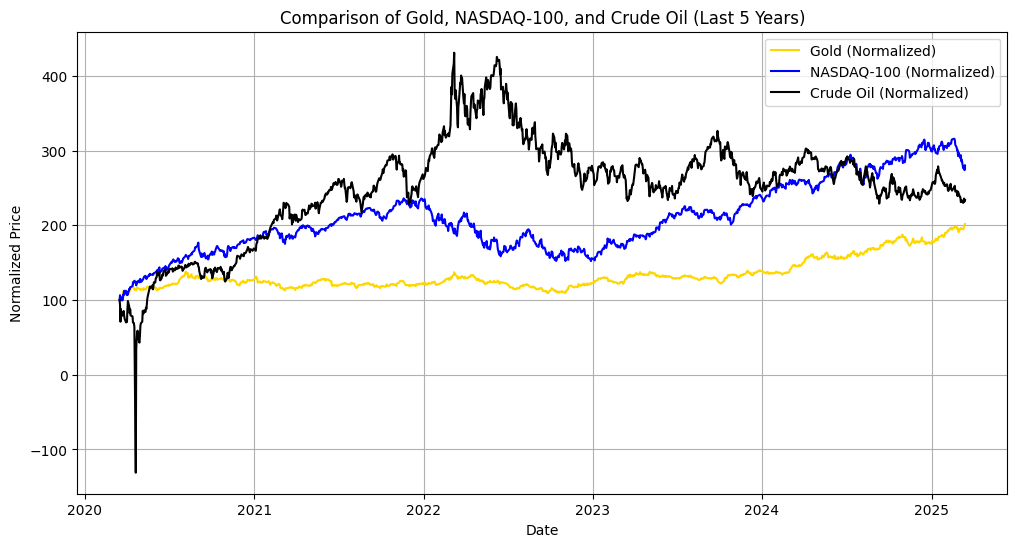

In [31]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download data for Gold, NASDAQ-100, and Crude Oil
gold = yf.download("GC=F", period="5y", interval="1d")
nasdaq = yf.download("^NDX", period="5y", interval="1d")
oil = yf.download("CL=F", period="5y", interval="1d")

# Check available columns
print("Gold columns:", gold.columns)
print("NASDAQ columns:", nasdaq.columns)
print("Oil columns:", oil.columns)

# Use 'Close' if 'Adj Close' is missing
gold_price = gold["Close"] if "Adj Close" not in gold.columns else gold["Adj Close"]
nasdaq_price = nasdaq["Close"] if "Adj Close" not in nasdaq.columns else nasdaq["Adj Close"]
oil_price = oil["Close"] if "Adj Close" not in oil.columns else oil["Adj Close"]

# Normalize prices (first value = 100)
gold_norm = (gold_price / gold_price.iloc[0]) * 100
nasdaq_norm = (nasdaq_price / nasdaq_price.iloc[0]) * 100
oil_norm = (oil_price / oil_price.iloc[0]) * 100

# Plot data
plt.figure(figsize=(12,6))
plt.plot(gold_norm, label="Gold (Normalized)", color='gold')
plt.plot(nasdaq_norm, label="NASDAQ-100 (Normalized)", color='blue')
plt.plot(oil_norm, label="Crude Oil (Normalized)", color='black')

# Formatting
plt.title("Comparison of Gold, NASDAQ-100, and Crude Oil (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid()
plt.show()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


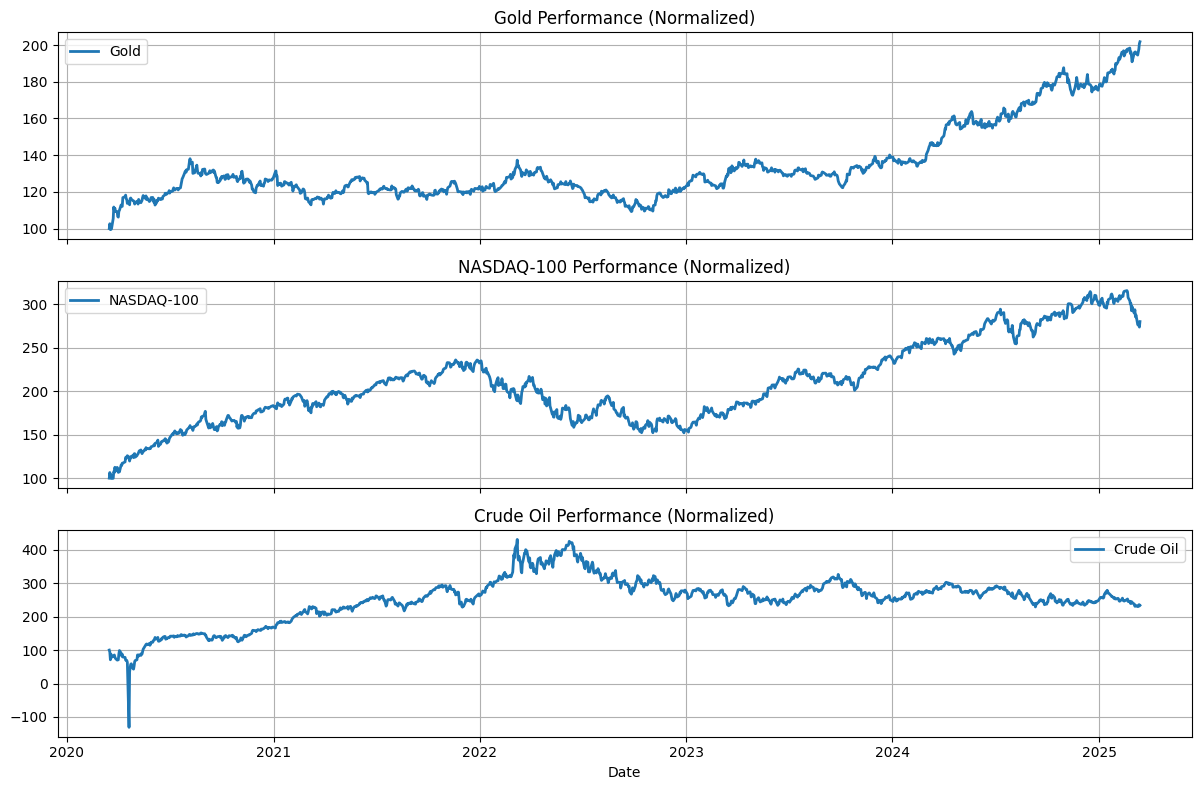

In [32]:

import matplotlib.pyplot as plt

# Download data
assets = {"Gold": "GC=F", "NASDAQ-100": "^NDX", "Crude Oil": "CL=F"}
data = {name: yf.download(ticker, period="5y", interval="1d")["Close"] for name, ticker in assets.items()}

# Normalize data
for name in data:
    data[name] = (data[name] / data[name].iloc[0]) * 100

# Plot with subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, (name, series) in zip(axes, data.items()):
    ax.plot(series, label=name, linewidth=2)
    ax.set_title(f"{name} Performance (Normalized)")
    ax.legend()
    ax.grid()

plt.xlabel("Date")
plt.tight_layout()
plt.show()


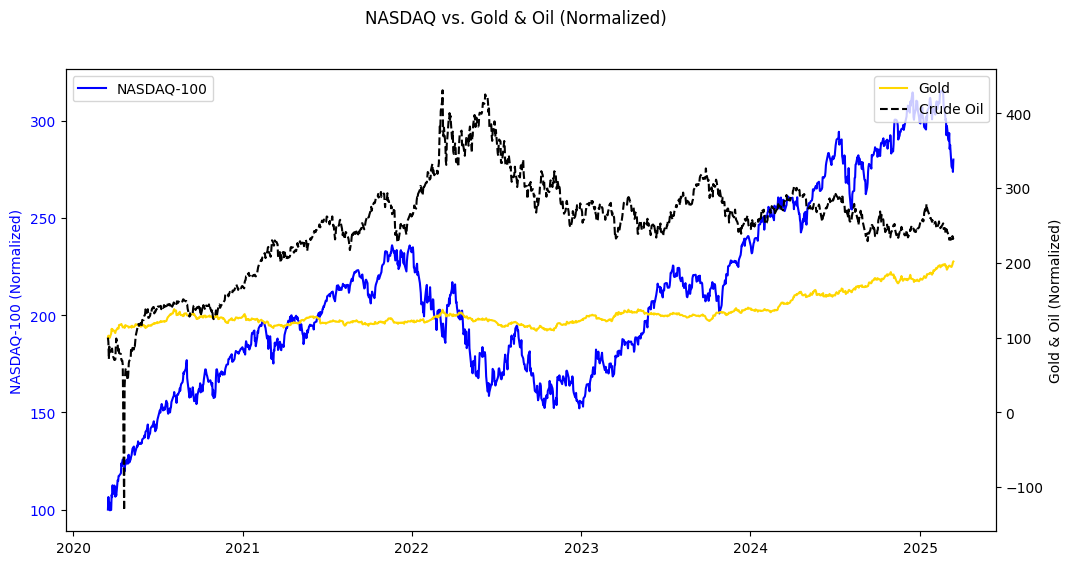

In [33]:
fig, ax1 = plt.subplots(figsize=(12,6))

# NASDAQ (Left Axis)
ax1.plot(data["NASDAQ-100"], color="blue", label="NASDAQ-100")
ax1.set_ylabel("NASDAQ-100 (Normalized)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Gold & Oil (Right Axis)
ax2 = ax1.twinx()
ax2.plot(data["Gold"], color="gold", label="Gold")
ax2.plot(data["Crude Oil"], color="black", linestyle="dashed", label="Crude Oil")
ax2.set_ylabel("Gold & Oil (Normalized)", color="black")
ax2.tick_params(axis="y", labelcolor="black")

fig.suptitle("NASDAQ vs. Gold & Oil (Normalized)")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()


[*********************100%***********************]  31 of 31 completed


Top 10 des actions les plus corrélées avec l'US100:
Ticker
ISRG     0.959331
GOOGL    0.958491
MSFT     0.952492
BKNG     0.935907
INTU     0.922220
META     0.915448
AMAT     0.914816
AAPL     0.914314
COST     0.912806
LRCX     0.911326
dtype: float64


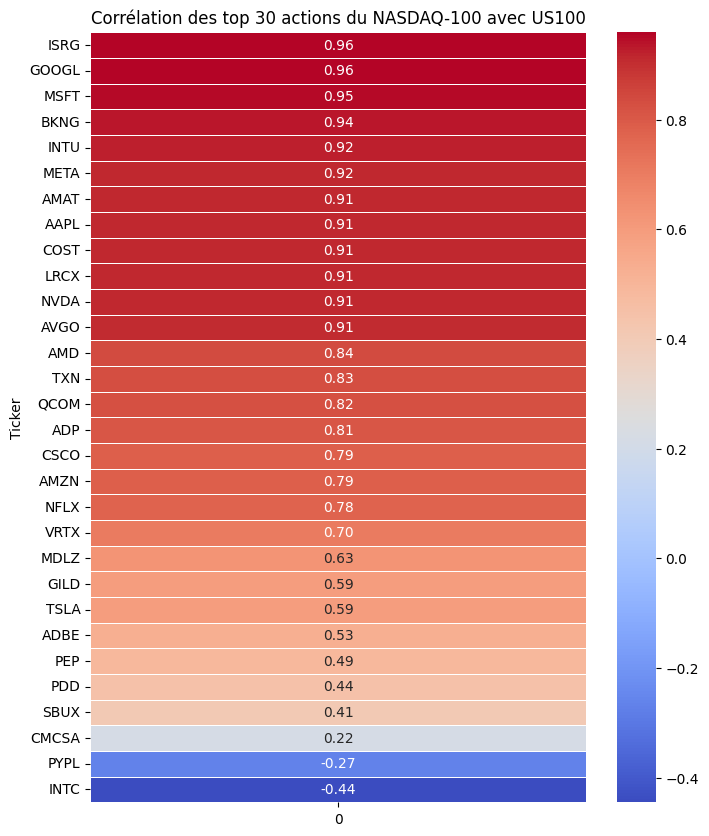

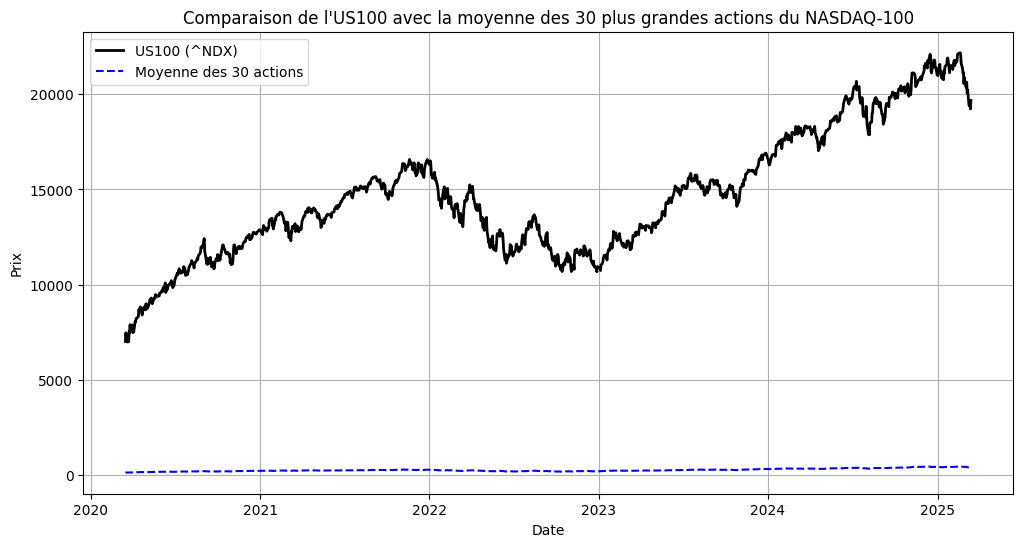

In [ ]:

import seaborn as sns


top_30_tickers = [
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META", "TSLA", "AVGO", "PEP", "COST",
    "ADBE", "NFLX", "AMD", "INTC", "CMCSA", "TXN", "QCOM", "AMAT", "PYPL", "SBUX",
    "INTU", "ISRG", "LRCX", "MDLZ", "CSCO", "BKNG", "GILD", "ADP", "VRTX", "PDD"
]

top_30_tickers.append("^NDX")  

data = yf.download(top_30_tickers, period="5y", interval="1d")["Close"]

# Supprimer les lignes contenant des NaN
data.dropna(inplace=True)

# Séparer les actions et l'indice
stocks = data.drop(columns=["^NDX"])  # Les actions
us100 = data["^NDX"]  # L'indice

# Calculer la corrélation entre chaque action et l'indice US100
correlation = stocks.corrwith(us100).sort_values(ascending=False)

# Afficher le top 10 des actions les plus corrélées avec l'US100
print("Top 10 des actions les plus corrélées avec l'US100:")
print(correlation.head(10))

# Tracer une heatmap de corrélation
plt.figure(figsize=(8, 10))
sns.heatmap(correlation.to_frame(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Corrélation des top 30 actions du NASDAQ-100 avec US100")
plt.show()

# Tracer l'évolution de l'indice et de la moyenne des actions
plt.figure(figsize=(12, 6))
plt.plot(data.index, us100, label="US100 (^NDX)", color="black", linewidth=2)
plt.plot(data.index, stocks.mean(axis=1), label="Moyenne des 30 actions", color="blue", linestyle="dashed")
plt.legend()
plt.title("Comparaison de l'US100 avec la moyenne des 30 plus grandes actions du NASDAQ-100")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.grid()
plt.show()


In [35]:
data["^NDX"]

Date
2020-03-16     7020.379883
2020-03-17     7473.950195
2020-03-18     7175.180176
2020-03-19     7288.520020
2020-03-20     6994.290039
                  ...     
2025-03-10    19430.949219
2025-03-11    19376.960938
2025-03-12    19596.019531
2025-03-13    19225.480469
2025-03-14    19672.667969
Name: ^NDX, Length: 1257, dtype: float64

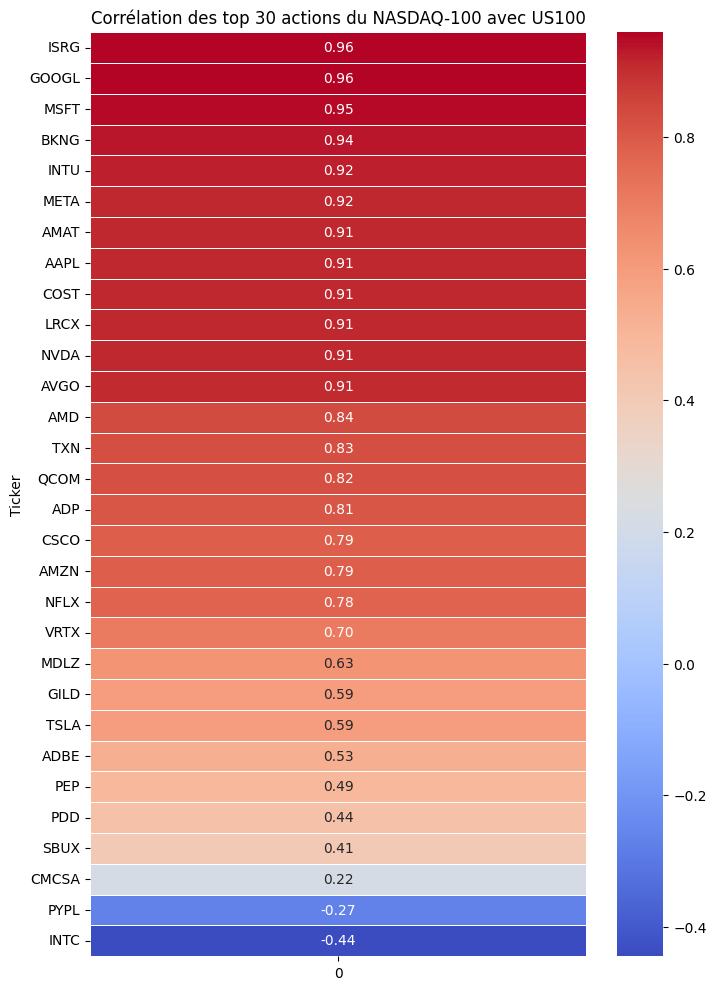

In [36]:
plt.figure(figsize=(8, 12))
sns.heatmap(correlation.to_frame(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Corrélation des top 30 actions du NASDAQ-100 avec US100")
plt.show()


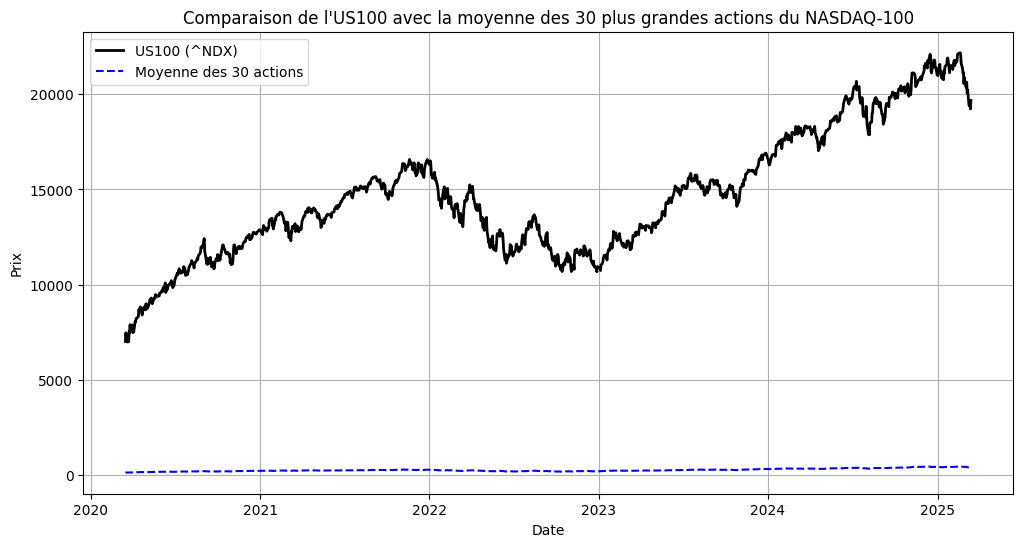

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, us100, label="US100 (^NDX)", color="black", linewidth=2)
plt.plot(data.index, stocks.mean(axis=1), label="Moyenne des 30 actions", color="blue", linestyle="dashed")
plt.legend()
plt.title("Comparaison de l'US100 avec la moyenne des 30 plus grandes actions du NASDAQ-100")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.grid()
plt.show()


C:\Users\Fares\AppData\Local\Temp\ipykernel_620\807332380.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




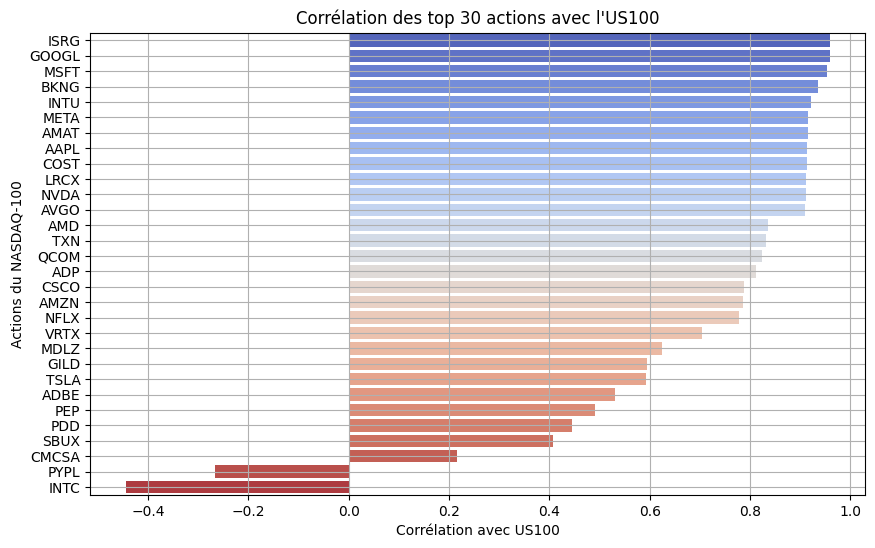

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation.values, y=correlation.index, palette="coolwarm")
plt.xlabel("Corrélation avec US100")
plt.ylabel("Actions du NASDAQ-100")
plt.title("Corrélation des top 30 actions avec l'US100")
plt.grid()
plt.show()


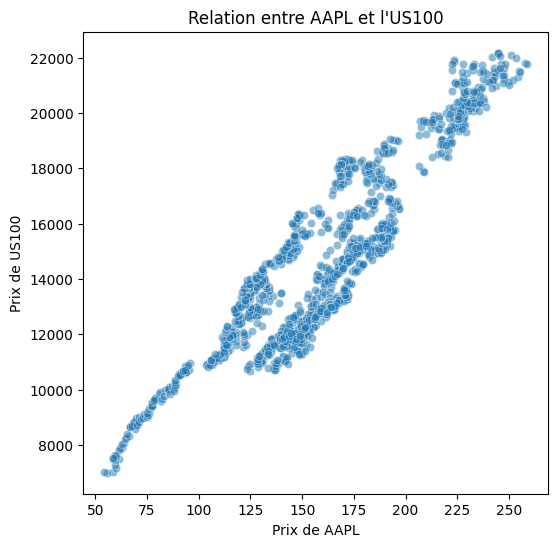

In [39]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=data["AAPL"], y=us100, alpha=0.5)
plt.xlabel("Prix de AAPL")
plt.ylabel("Prix de US100")
plt.title("Relation entre AAPL et l'US100")
plt.show()


In [40]:
data.head()

Ticker,AAPL,ADBE,ADP,AMAT,AMD,AMZN,AVGO,BKNG,CMCSA,COST,...,NVDA,PDD,PEP,PYPL,QCOM,SBUX,TSLA,TXN,VRTX,^NDX
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-16,58.779289,286.029999,110.836411,38.712803,38.709999,84.457497,16.283533,1275.722412,31.697836,260.511841,...,4.891976,32.189999,98.609047,92.720001,57.861755,52.614414,29.671333,81.342270,199.770004,7020.379883
2020-03-17,61.363808,311.809998,117.108635,42.848660,41.880001,90.391998,17.319159,1353.462402,33.615181,282.415924,...,5.411811,33.389999,111.365707,97.870003,61.792194,52.964638,28.680000,92.347420,210.440002,7473.950195
2020-03-18,59.861637,294.609985,106.437698,37.423340,39.119999,91.500000,14.572537,1220.407104,31.381203,282.885071,...,5.051887,31.770000,105.436417,91.459999,54.909435,50.584919,24.081333,86.997086,212.979996,7175.180176
2020-03-19,59.402966,307.510010,106.229546,38.388046,39.820000,94.046501,16.879904,1178.594360,31.609871,280.787659,...,5.304706,33.799999,102.314850,93.690002,58.328384,55.146809,28.509333,88.362930,215.690002,7288.520020
2020-03-20,55.631744,295.339996,101.423569,36.286678,39.610001,92.304497,16.969954,1164.696289,29.349514,267.172272,...,5.124867,33.570000,90.621971,86.680000,54.658180,52.111530,28.502001,84.909157,206.000000,6994.290039


In [45]:
import pandas as pd
import numpy as np 
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.preprocessing import  LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans 


In [47]:
X=data.drop("^NDX",axis=1)
y=data["^NDX"]

In [48]:
lb= LabelEncoder()
y_lb=lb.fit_transform(y)

In [49]:
X_train,X_test,y_train_lb,y_test_lb=train_test_split(X,y_lb,random_state=42,test_size=0.3)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.3)

In [50]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train_lb)


KNeighborsClassifier(n_neighbors=3)

In [51]:
knn_predct=knn.predict(X_test)
print(knn_predct)

[ 890  134   48   54 1115  913  979  194 1217  980  875 1035  386 1070
 1056  760  974 1056  674  700  974  257  496  308 1151 1122 1092  388
 1235   36 1035  653  222  228  446  876  534  475 1115  357 1211  373
 1205  129 1022 1194  548   21  957 1222  593  407  902  711  541  412
  383  268 1209  852  876  534  914   81   60 1140  446   75  262   50
 1217   74 1030  193  200  482  983   88  914 1235  703  715  625  534
  919  148  362  200  952  312  628 1006  502  777   43  145  551   27
   25  569  808  593  190   87  373  421  283  875  888 1115  895  593
  135 1140  553  381  217  200  521  511   68 1005 1035  145  110  308
  843  858  743  712 1180  579  134  958 1005  111  194  913  375 1056
  882  198 1195  980  373 1205  243 1142 1035  509  731   48  882  936
   50  147  844  633  512 1178  531  882  826  341   90  232 1030  531
  421  732  843  232  858  458  354  725  619  432  592  268  585 1190
  124  639  804  857  334  928  688  413  423  501  636  426  793    7
  202 

In [52]:
ln_model = LinearRegression()
ln_model.fit(X_train,y_train)
ln_pred=ln_model.predict(X_test)

In [63]:
data["^NDX"].iloc[-1]

np.float64(19672.66796875)

In [62]:
ln_pred

array([15740.35836658, 11196.96837464,  9400.02665161,  9759.99007481,
       19743.60885489, 16268.62155954, 17352.96144555, 11697.31332312,
       21348.08823959, 17654.60016475, 15959.09700834, 18558.84857389,
       12748.31831586, 19079.28360557, 18654.07875397, 14950.71109288,
       17728.09193172, 18853.37880578, 14837.30357784, 15096.31174752,
       17642.24972659, 12049.04118271, 13457.87292864, 12097.53470681,
       20356.24647154, 20301.502377  , 19856.1342249 , 12833.89502585,
       21126.3518618 ,  9169.06271012, 18277.76911986, 14515.81368911,
       11907.55544374, 11840.96420148, 12735.12961349, 16034.19046623,
       13779.12543121, 13283.41537555, 19793.52159656, 12738.1811808 ,
       21108.75513901, 12806.03622252, 21543.05136969, 11390.31087464,
       18214.36649643, 20744.41349727, 13879.12373214,  8902.58200715,
       16745.64727799, 21743.72424458, 14277.64859583, 12762.86577619,
       15982.1894259 , 15214.427212  , 13637.01799213, 12452.63058543,
      

In [53]:
ln_rmse = mean_squared_error(y_test,ln_pred)
ln_rae = mean_absolute_error(y_test,ln_pred)
ln_r2 = r2_score(y_test,ln_pred)
print("rmse:",ln_rmse,"rae:",ln_rae,"r2:",ln_r2)


rmse: 3166.1533796765943 rae: 45.10529266763497 r2: 0.9996920701727965


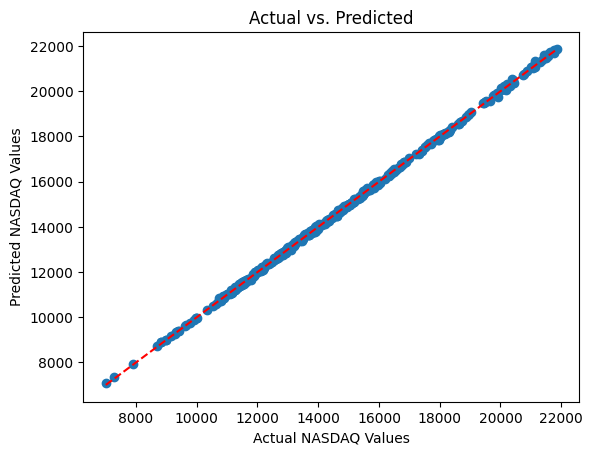

In [54]:
import matplotlib.pyplot as plt

plt.scatter(y_test, ln_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual NASDAQ Values')
plt.ylabel('Predicted NASDAQ Values')
plt.title('Actual vs. Predicted')
plt.show()

In [55]:
lasso_model = Lasso()
lasso_model.fit(X_train,y_train)
lasso_pred=lasso_model.predict(X_test)

c:\Users\Fares\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.928e+06, tolerance: 9.768e+05



In [64]:
lasso_pred

array([15773.15108355, 11198.36000972,  9387.46091284,  9767.83287537,
       19738.33790735, 16240.92815769, 17366.55534919, 11727.80734064,
       21336.85517305, 17657.22075916, 15932.8635708 , 18552.8413339 ,
       12763.8555501 , 19104.87492006, 18679.89346534, 14943.66082243,
       17729.71991068, 18879.13081308, 14846.13959283, 15105.09939262,
       17643.03055503, 11997.93568233, 13474.87593871, 12104.79353333,
       20262.78664375, 20266.34442258, 19814.1594279 , 12821.74677549,
       21147.93020644,  9144.26004901, 18259.54089951, 14530.49443527,
       11924.51086176, 11794.56339396, 12708.12918723, 16024.21980294,
       13807.2509932 , 13320.54976778, 19840.63951266, 12741.89076304,
       21087.55953457, 12798.81948377, 21459.68034684, 11357.47454902,
       18194.11423079, 20754.00094559, 13883.30806085,  8876.66174048,
       16699.55329212, 21792.35109016, 14255.52970989, 12771.9841136 ,
       16012.80840832, 15229.22139377, 13640.07890674, 12433.09546948,
      

In [56]:
lasso_rmse = mean_squared_error(y_test,lasso_pred)
lasso_rae = mean_absolute_error(y_test,lasso_pred)
lasso_r2 = r2_score(y_test,lasso_pred)
print("rmse:",lasso_rmse,"rae:",lasso_rae,"r2:",lasso_r2)


rmse: 4315.919393090673 rae: 52.64105859793726 r2: 0.9995802476527292


In [57]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

km_train , km_test = train_test_split(data_scaled,random_state=42,test_size=0.3)

In [58]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(km_train)
kmeans_pred= kmeans.predict(km_test)

In [59]:
kmeans_pred

array([2, 0, 0, 0, 1, 2, 1, 2, 1, 1, 2, 1, 0, 1, 1, 2, 1, 1, 2, 2, 1, 2,
       0, 2, 1, 1, 1, 0, 1, 0, 1, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 2, 1, 0,
       1, 1, 2, 0, 1, 1, 2, 0, 2, 2, 0, 0, 0, 0, 1, 2, 2, 2, 2, 0, 0, 1,
       2, 0, 2, 0, 1, 0, 1, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 2, 2, 1, 2, 2, 0, 0, 2, 0, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1,
       2, 2, 0, 1, 0, 2, 0, 2, 2, 2, 0, 1, 1, 0, 2, 2, 2, 2, 2, 2, 1, 2,
       0, 1, 1, 2, 2, 2, 0, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 2, 2, 0, 2, 2,
       0, 0, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 2, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 2,
       1, 2, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 0, 1, 1, 0, 0, 2, 2, 2, 1, 2,
       2, 0, 0, 1, 1, 2, 1, 1, 1, 2, 0, 2, 2, 2, 2, 1, 1, 0, 0, 2, 0, 0,
       2, 1, 0, 2, 0, 0, 2, 2, 0, 2, 2, 0, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1,
       1, 1, 0, 2, 2, 0, 2, 1, 2, 2, 2, 0, 2, 1, 2, 1, 2, 1, 1, 1, 2, 0,
       2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 0, 0, 2,

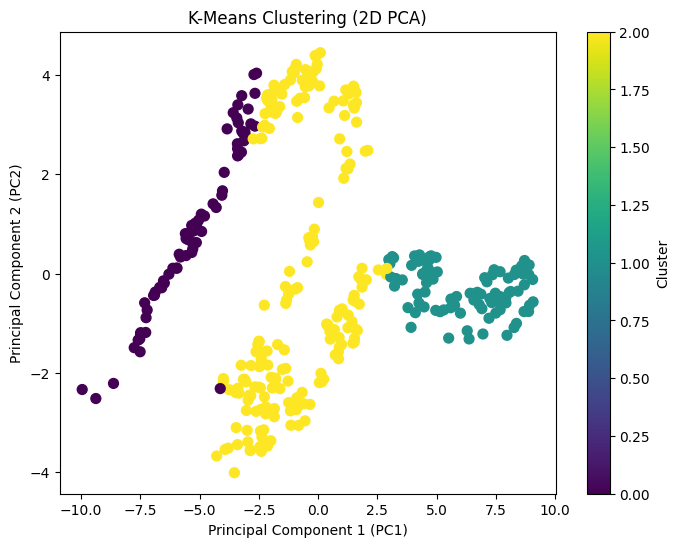

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled) 
pca_test = pca.transform(km_test)  

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_test[:, 0], pca_test[:, 1], c=kmeans_pred, cmap='viridis', s=50)


plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('K-Means Clustering (2D PCA)')


plt.colorbar(scatter, label='Cluster')


plt.show()